# LCLS Areas

Areas are delinated by BEG and END markers.

In [1]:
from pytao import Tao

import os

%pylab --no-import-all inline
%config InlineBackend.figure_format='retina'

Populating the interactive namespace from numpy and matplotlib


In [2]:
# All models
mdir = os.path.expandvars('$LCLS_LATTICE/bmad/models/')
[d for d in os.listdir(mdir) if os.path.isdir(mdir+d)]

['cu_sxr',
 'hxr',
 'cu_spec',
 'lcls_complex',
 'sc_diag0',
 'cu_hxr',
 'cu_inj',
 'sc_dasel',
 'cu_linac',
 'sc_sxr',
 'sc_hxr',
 'sc_bsyd']

In [3]:
MODEL = 'cu_hxr'
tao = Tao(f'-init $LCLS_LATTICE/bmad/models/{MODEL}/tao.init -noplot')

In [4]:
NAMES = tao.lat_ele_list(branch_name=0)
NAMES.index('END')

3027

In [5]:
ix_of = {}
duplicates = []
for ix, name in enumerate(NAMES):
    if name not in ix_of:
        ix_of[name] = ix
    else:
        duplicates.append(name)
#list(set(duplicates))

In [6]:
def get_floor(tao, elename):
    dat = tao.ele_floor(elename)
    xyz = dat['Reference'][0:3]
    return xyz
get_floor(tao, 'BEGINNING')

array([  10.44893,    0.     , 2017.91148])

In [7]:
def get_area_info(tao, areaname):
    begname = f'BEG{areaname}'
    endname = f'END{areaname}'
    x0, y0, z0 = get_floor(tao, begname)
    x1, y1, z1 = get_floor(tao, endname)
    
    d = dict(area=areaname,
             x0=x0, y0=y0, z0=z0,
             x1=x1, y1=y1, z1=z1,
             x_center=(x0+x1)/2,
             y_center=(y0+y1)/2,
             z_center=(z0+z1)/2)
    return d
get_area_info(tao, 'GUN')

{'area': 'GUN',
 'x0': 10.44893,
 'y0': 0.0,
 'z0': 2017.91148,
 'x1': 9.88806155109982,
 'y1': 0.0,
 'z1': 2018.71248315734,
 'x_center': 10.16849577554991,
 'y_center': 0.0,
 'z_center': 2018.31198157867}

In [8]:
def get_area_names(tao):
    begnames = tao.lat_list('BEG*', 'ele.name')
    areas = [n[3:] for n in begnames[1:]]
    return areas
get_area_names(tao)

['GUN',
 'L0',
 'DL1_1',
 'DL1_2',
 'L1',
 'BC1',
 'L2',
 'BC2',
 'L3',
 'CLTH_0',
 'CLTH_1',
 'CLTH_2',
 'BSYH_1',
 'BSYH_2',
 'LTUH',
 'UNDH',
 'DMPH_1',
 'DMPH_2']

In [9]:
def get_reference_orbit(tao):
    ixend = tao_lat_ele_list(tao).index('END')
    return  np.array([get_floor(tao, ele) for ele in range(ixend)]).T

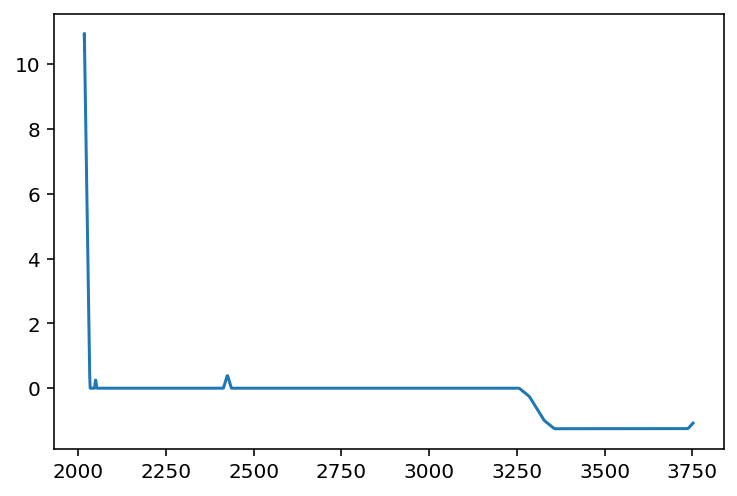

In [10]:
floors = np.array([get_floor(tao, ele) for ele in range(3000)])
plt.plot(floors[:,2], floors[:,0])

In [11]:
%%tao
sho ele DH01

-------------------------
Tao> sho ele DH01
Element # 103
Element Name: DH01
Element Type:  "CSR"
Key: Drift
S_start, S:      9.201652,      9.343481
Ref_time:  3.118802E-08

Attribute values [Only non-zero values shown]:
    1  L                           =  1.4182840E-01 m
   50  DELTA_REF_TIME              =  4.7309200E-10 sec
   53  P0C                         =  1.3499903E+08 eV           BETA                        =  9.9999284E-01
   54  E_TOT                       =  1.3500000E+08 eV           GAMMA                       =  2.6418841E+02
   65  INTEGRATOR_ORDER            = 0
   67  DS_STEP                     =  1.4182840E-01 m        66  NUM_STEPS                   = 1
   68  CSR_DS_STEP                 =  0.0000000E+00 m

       TRACKING_METHOD              =  Bmad_Standard             APERTURE_AT                =  Exit_End
       MAT6_CALC_METHOD             =  Bmad_Standard             APERTURE_TYPE              =  Rectangular
       SPIN_TRACKING_METHOD         =  Trackin

In [12]:
begnames = tao.cmd('python lat_list 1@0>>BEG*|model ele.name')
endnames = tao.cmd('python lat_list 1@0>>END*|model ele.name')
areas = [n[3:] for n in begnames[1:]]

In [13]:
print('Model:', MODEL)
for area in areas:
    info = get_area_info(tao, area)
    z0 = info['z0']
    z1 = info['z1']
    print(f'{area:10} {z0:10.3f} {z1:10.3f}')

Model: cu_hxr
GUN          2017.911   2018.712
L0           2018.712   2024.791
DL1_1        2024.791   2031.992
DL1_2        2031.992   2035.035
L1           2035.035   2044.167
BC1          2044.167   2059.733
L2           2059.733   2410.698
BC2          2410.698   2438.400
L3           2438.400   3042.005
CLTH_0       3042.005   3050.512
CLTH_1       3050.512   3058.457
CLTH_2       3058.457   3110.961
BSYH_1       3110.961   3117.409
BSYH_2       3117.409   3224.022
LTUH         3224.022   3562.739
UNDH         3562.739   3718.483
DMPH_1       3718.483   3734.407
DMPH_2       3734.407   3765.481


In [14]:
def reference_orbit_to_axes(tao, axes, color='black'):
    dat = np.array([get_floor(tao, ele) for ele in tao.lat_list('END*', 'ele.name')]).T
    ax.plot(dat[2], dat[0], color=color)

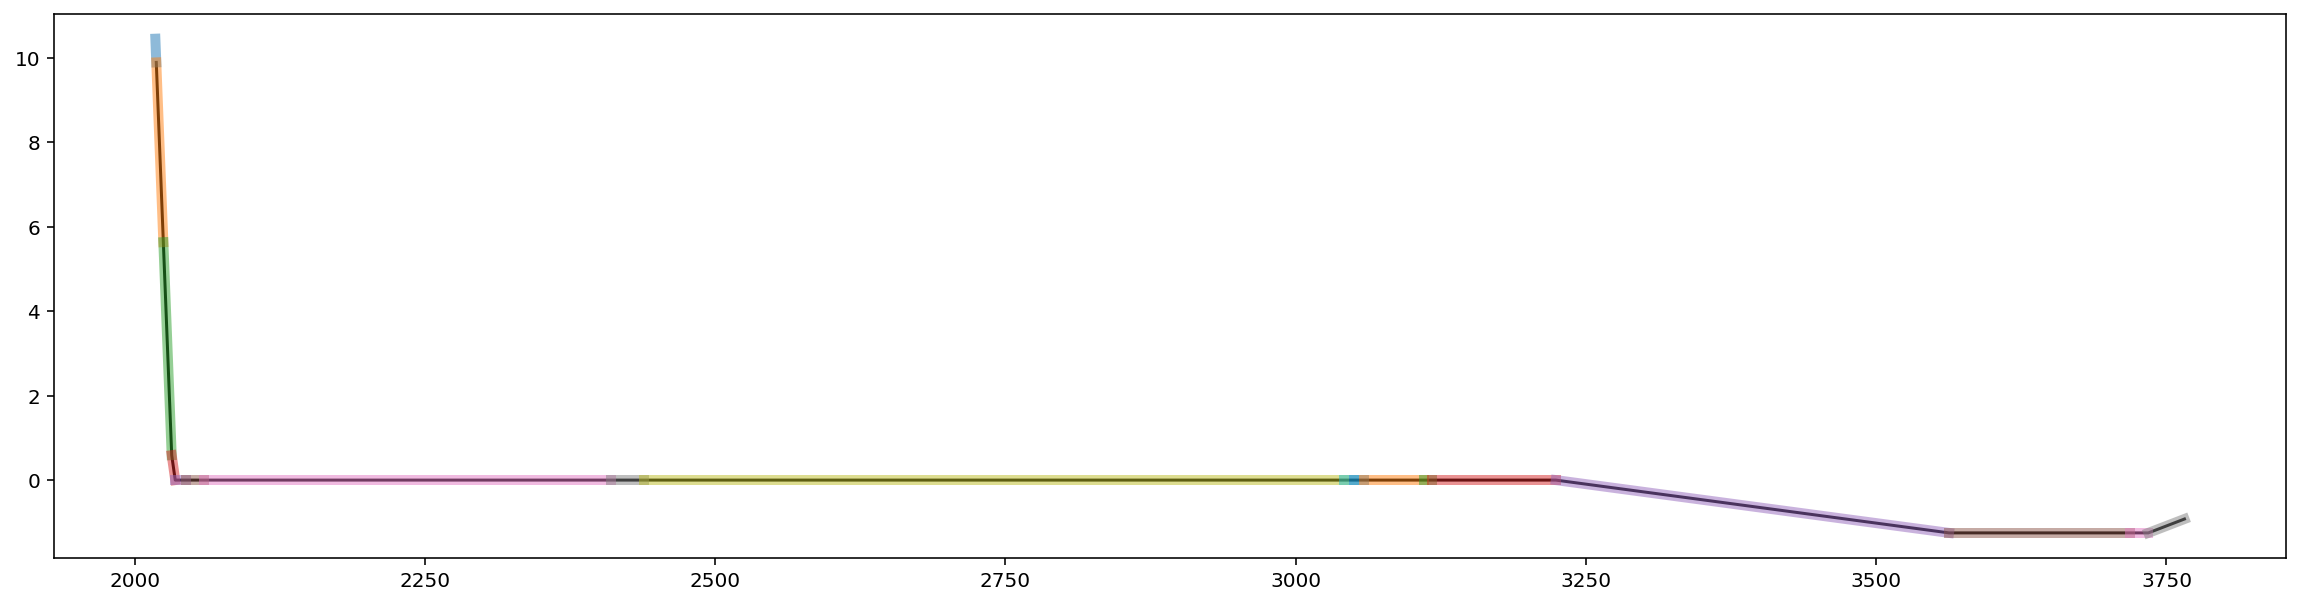

In [15]:

def area_line_to_axes(tao, areaname, axes):
    d = get_area_info(tao, areaname)
    
    ax.plot([d['z0'], d['z1']], [d['x0'], d['x1']], alpha=0.5, linewidth=5)
    return ax

fig, ax = plt.subplots(figsize=(20,5))
reference_orbit_to_axes(tao, ax)
for area in get_area_names(tao):
    area_line_to_axes(tao, area, ax)
    
    

In [16]:
MYMODELS = ['cu_sxr',
 #'hxr',
 'cu_spec',
 #'lcls_complex',
 'sc_diag0',
 'cu_hxr',
 #'cu_inj',
 #'sc_dasel',
# 'cu_linac',
 'sc_sxr',
 'sc_hxr']

cu_sxr
cu_spec
sc_diag0
cu_hxr
sc_sxr
sc_hxr


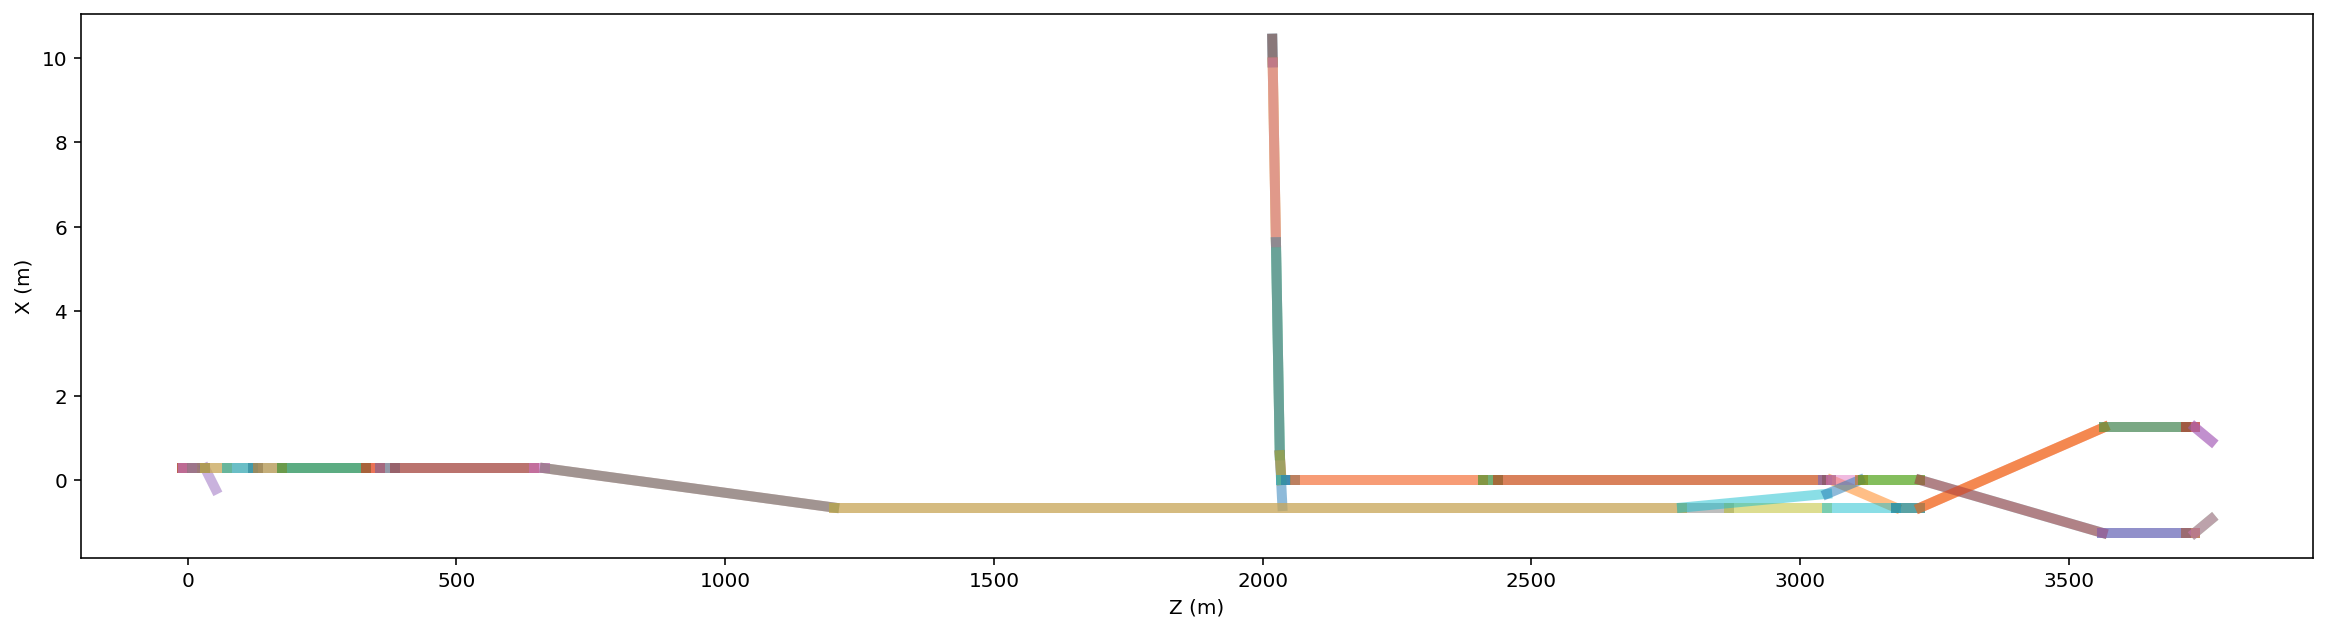

In [17]:
fig, ax = plt.subplots(figsize=(20,5))
ax.set_xlabel('Z (m)')
ax.set_ylabel('X (m)')
for model in MYMODELS:
    print(model)
    tao = Tao(f'-init $LCLS_LATTICE/bmad/models/{model}/tao.init -noplot')
    areas = get_area_names(tao)
    for area in areas:
        area_line_to_axes(tao, area, ax)    

# Bokeh

In [18]:
from bokeh.plotting import figure, output_notebook, output_file, show
from bokeh.models import ColumnDataSource
output_notebook()


from bokeh.palettes import d3
CLIST = d3['Category20c'][20]

Loading BokehJS ...

In [19]:
source = ColumnDataSource(data=dict(
    x=[1, 2, 3, 4, 5],
    y1=[1, 2, 4, 3, 4],
    y2=[1, 4, 2, 2, 3],
))
p = figure(plot_width=400, plot_height=400)

p.vline_stack(['y1', 'y2'], x='x', source=source)

show(p)

In [20]:
def add_line_to_plot(tao, areaname, plot, color=None):
    d = get_area_info(tao, areaname)
    plot.line([d['z0'], d['z1']], [d['x0'], d['x1']], color=color)
    plot.text([d['z_center']], [d['x_center']], text=[areaname], color=color)

In [21]:
def add_reference_orbit_to_plot(tao, plot, color='black'):
    dat = np.array([get_floor(tao, ele) for ele in tao.lat_list('END*', 'ele.name')]).T
    plot.line(dat[2], dat[0], color=color)

In [22]:
tao = Tao(f'-init $LCLS_LATTICE/bmad/models/cu_spec/tao.init -noplot')

p = figure(plot_width=1200, plot_height=400, x_axis_label = 'Z (m)')
add_line_to_plot(tao, 'GUN', p, color=CLIST[0])
add_reference_orbit_to_plot(tao, p)
show(p)

In [23]:
output_file('lcls_areas.html')
show(p)

In [24]:
ii = 0

p = figure(plot_width=1600, plot_height=400, title='LCLS Areas',
           x_axis_label = 'Z (m)',
           y_axis_label = 'X (m)')
for model in MYMODELS:
    tao = Tao(f'-init $LCLS_LATTICE/bmad/models/{model}/tao.init -noplot')
    add_reference_orbit_to_plot(tao, p)
    areas = get_area_names(tao)
    for area in areas:
        if ii >= len(CLIST):
            ii = 0        
        color = CLIST[ii]
        ii += 1
        add_line_to_plot(tao, area, p, color=color)   
show(p)

In [ ]:
#!scp lcls_areas.html slac:/u/ad/cmayes/public_html/lcls_areas/index.html